# Time-Frecuency
*  Jose Gonzalez Lopez
*  Mykola Liashuha

# Introduction
In this notebook we will be applying some denoising techniques in the frecuency domain. We will first create some noise data as we did on the previous exercise and then we will try to recover the original data by spectral substraction. During that process, we will document our findings to try to clean the signal as much as possible to conclude the work in the final section.

# Imports

In [1]:
import scipy #Library for signal analysis
import matplotlib.pyplot as plt #Plot
import numpy as np #Operations
import cv2 #Read images and do operations
import IPython.display as ipd
import numpy.random #For generating noise

from IPython.display import Audio #Display audio

from scipy import signal #Basic libraries
from scipy.io import wavfile #Read wavfiles
from scipy.signal import welch,stft,istft #Get power density estimated, short fourier transform

# Auxiliar Functions

In [2]:
'''
Read the audio file properly, there are problems if we do not cast to double
wavfile_name: the path to the wavfile
'''
def read_file_PROPERLY(wavfile_name):
    samplerate_music, data_music = wavfile.read(wavfile_name) #Read the file
    data_music=data_music.astype(np.double)/2**15
    return samplerate_music,data_music

In [3]:
'''
Signal-to-noise ratio
x: original signal
y: changed(noisy) signal
'''
def snr(x, y):
    #return 20*np.log10(np.sqrt(np.sum(np.square(x)))/np.sqrt(np.sum(np.square(x-y)))) #This version does not work, mystery :)
    return 20*np.log10(np.linalg.norm(x)/np.linalg.norm(x-y)) #This one works properly

In [4]:
'''
This function return the hard thresholding of a noisy signal
noisy_signal: signal w/ signal with stft
power_density_spectrum: the power density spectrum of the noise applied to the noisy signal
lbda: lambda parameter of the hard thresholding
'''
def hard_thresholding(noisy_signal,power_density_spectrum,lbda):
    pdsa=(lbda*np.abs(power_density_spectrum)).reshape(-1,1)
    nsa=np.abs(noisy_signal)
    
    comparison=(nsa>pdsa)
    
    first=noisy_signal
    second=0
    
    denoised_signal=np.where(comparison,first,second)
    return denoised_signal

In [5]:
'''
This function returns the spectral substraction of a noisy signal
noisy_signal: signal w/ signal with stft
power_density_spectrum: the power density spectrum of the noise applied to the noisy signal
lbda: lambda parameter of the spectral substraction
'''
def spectral_substraction(noisy_signal,power_density_spectrum,lbda):
    nsa=np.abs(noisy_signal)**2
    pdsa=np.abs(power_density_spectrum)**2
    lbdaa=lbda**2
    prod=(lbdaa*pdsa).reshape(-1,1)
    
    up=prod
    down=nsa
    op=(1-(up/down)) 
    op[op<0]=0
    
    denoised_signal = noisy_signal*op
    
    return denoised_signal
    

In [6]:
'''
This function returns the general spectral substraction of a noisy signal
noisy_signal: noisy_signal with short fourier transform
lbda: lambda for formula, parameter we will discuss
power_density_spectrum: estimation of the power spectrum of original signal using welch method
alpha: alpha for formula, parameter we will discuss
beta: beta for formula, parameter we will discuss
gamma: gamma for formula, parameter we will discuss
'''

def general_spectral_substraction(noisy_signal,power_density_spectrum,lbda,alpha,beta,gamma):
    nsa=np.abs(noisy_signal)**alpha
    pdsa=np.abs(power_density_spectrum)**alpha
    lbdaa=lbda**alpha
    prod=(lbdaa*pdsa).reshape(-1,1)
    
    comparison=(nsa>prod)
    
    up=prod
    down=nsa
    op_1=(1-(up/down))**beta #Negative Numbers may appear
    
    first=noisy_signal*op_1
    
    second=((gamma*noisy_signal)/(np.abs(noisy_signal)))*np.abs(power_density_spectrum).reshape(-1,1)
    
    denoised_signal=np.where(comparison,first,second)
    
    return denoised_signal

In [7]:
def audio_to_frames(y: np.array, m, hop_size, fs) -> np.array:
    """Convert y[n] into a matrix of frames Y_m(w) where each row is a time slice"""   
    _, _, Zxx = signal.stft(y, fs=fs, nperseg=m, noverlap=hop_size, nfft=m*8)
    return Zxx.T

def frames_to_audio(Y: np.array, m, hop_size, fs) -> np.array:
    """Convert Y_m(w) matrix of frames into a 1D signal y[n] using Overlap-Add"""
    _, xrec = signal.istft(Y.T, fs=fs, nperseg=m, noverlap=hop_size, nfft=m*8)
    return xrec

In [9]:
def noise_estimation_snr(Y: np.array) -> (np.array, np.array):
    """Estimates the magnitude and power spectrum of the noise for each frame"""
    
    # Prepare the output variables
    est_Mn = np.zeros(Y.shape)
    est_Pn = np.zeros(Y.shape)
    
    N = 10 # Number of frames to use for estimating a-posteriori SNR
    
    # Iterate through each frame and estimate noise
    for m in range(Y.shape[0]):
        if m < N:
            # Use noisy spectra for first 10 iterations
            est_Mn[m] = abs(Y[m])
            est_Pn[m] = est_Mn[m] ** 2
        else:
            a = 25
            # A-posteriori SNR            
            gammak = (abs(Y[m])**2)/np.mean(abs(Y[m-N:m])**2, axis=0) 
            alpha = 1/(1+np.exp(-a*(gammak-1.5)))
            est_Mn[m] = alpha * abs(est_Mn[m-1]) + (1-alpha) * abs(Y[m])
            est_Pn[m] = alpha * (abs(est_Mn[m-1])**2) + (1-alpha) * (abs(Y[m])**2)
            
    return est_Mn, est_Pn

In [8]:
def spec_subtract_mag(Y, est_Mn) -> np.array:
    est_magX = np.maximum(abs(Y) - est_Mn, 0)
    est_phaseX = np.angle(Y)
    est_Sx = est_magX * np.exp(1j*est_phaseX)
    return est_Sx

def spec_subtract_pow(Y, est_Pn) -> np.array:
    est_powX = np.maximum(abs(Y)**2 - est_Pn, 0)
    est_phaseX = np.angle(Y)
    est_Sx = np.sqrt(est_powX) * np.exp(1j*est_phaseX)
    return est_Sx

# Data
We will be using the music signal as the previous notebook. We will do some basic data exploration to listen to the melody and see the data plotted in 2D.

In [10]:
samplerate_music, data_music = read_file_PROPERLY("music.wav") #Read the file
ipd.Audio(data_music, rate=samplerate_music)

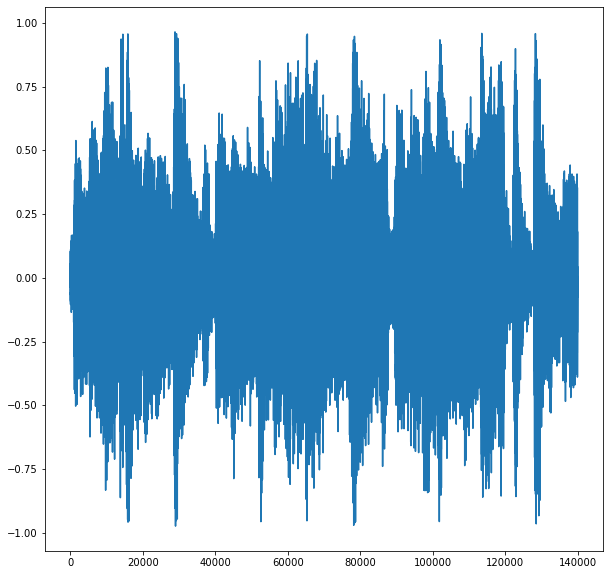

In [11]:
plt.figure(figsize=(10,10))
plt.plot(data_music)

# Noisy versions
To create the noisy versions of the melody, we will make use of the noise files provided for this notebook and we are going to measure its SNR to have a baseline to improve the noisy versions. 

$$SNR(y∣x)=20*log_{10}( \frac{∥x∥^{2}_{2}}{∥x-y∥^{2}_{2}}) \\
where\ x\ is\ original\ signal,\ y\ is\ noisy\ signal\ and\ ∥\ is\ absolute\ norm\ (2nd\ Norm)$$

We will denoise them using spectral substraction.

In [12]:
#Read noise files
sample_rate_noise, data_music_noise_1 = read_file_PROPERLY("noise1.wav")  
_, data_music_noise_2 = read_file_PROPERLY("noise2.wav") 
_, data_music_noise_3 = read_file_PROPERLY("noise3.wav") 

#Keep the noises
noises=[0.5*data_music_noise_1,0.4*data_music_noise_2,0.3*data_music_noise_3]

#Create the noisy versions
noisy_musics=[]
for noise in noises:
    noisy_musics.append(data_music+noise)

#Print the SNR of each one of them
for d in noisy_musics:
    print("Noise version with ",snr(data_music,d), " SNR")

Noise version with  6.599801433962856  SNR
Noise version with  7.931173209995414  SNR
Noise version with  11.072982685229649  SNR


In [13]:
ipd.Audio(noisy_musics[0], rate=samplerate_music)

In [14]:
ipd.Audio(noisy_musics[1], rate=samplerate_music)

In [15]:
ipd.Audio(noisy_musics[2], rate=samplerate_music)

# Denoising


Given:
$$y=x+n$$ 

where

$x∈\mathbb{R}^{N}$ is the clean signal

$n\in\mathbb{R}^{N}$ is a stationnary noise with known (or estimated) power density spectrum $S_{n}(\nu)$

$y\in\mathbb{R}^{N}$ is the noisy observation

Taking the STFT of the equation, we have for all $\tau,\nu:Y(\tau,\nu) = X(\tau,\nu) + S_{n}(\nu)$. The goal is to estimate $X(\tau,\nu)$. In order to do it, we will use hard thresholding

$$X(τ,ν)= \begin{cases} Y(τ,ν) & \mbox{if } |Y(\tau,\nu)|\gt \lambda|S_{n}(\nu)|\\ 0 & \mbox{if } |Y(\tau,\nu)|\leq \lambda|S_{n}(\nu)| \end{cases}$$


the spectral substraction

$$X(τ,ν)=Y(τ,ν)\left(1−\cfrac{\lambda^{2}|S_{n}(\nu)|^{2}}{|Y(\tau,\nu)|^{2}}\right)^{+}$$

where $(x)^{+}=max(x,0)$

and the general spectral substraction

$$X(τ,ν)= \begin{cases} Y(τ,ν)\left(1−\cfrac{\lambda^{\alpha}|S_{n}(\nu)|^{\alpha}}{|Y(\tau,\nu)|^{\alpha}}\right)^{\beta} & \mbox{if } |Y(\tau,\nu)|^{\alpha}\gt \lambda^{\alpha}|S_{n}(\nu)|^{\alpha}\\ \gamma \cfrac{Y(\tau,\nu)}{|Y(\tau,\nu)|} |S_{n}(\nu)| & \mbox{if } |Y(\tau,\nu)|^{\alpha}\leq \lambda^{\alpha}|S_{n}(\nu)|^{\alpha} \end{cases}$$

where $\lambda$, $\alpha$, $\beta$ and $\gamma$ will be some parameters that we will have to tune up to get better results.

## Hard thresholding 
Below is the hard thresholding implementation and the results.

In [16]:
denoised_signals_1=[data_music_noise for data_music_noise in noisy_musics] #List of denoised signals
snr_1={} #Keep track of best snr

#Initialization of dictionary to keep things tidy
for i in range(0,len(noisy_musics)):
    snr_ratio=snr(data_music,noisy_musics[i])
    snr_1[i]=[snr_ratio,[]]

#Try different parameters
lambdas=np.arange(1,1000,10)

#Loop through all noisy signals
for i in range(len(noises)):
    #Loop through all the parameters
    for param1 in lambdas:
        f_stft,t,Zxx=stft(noisy_musics[i],samplerate_music) #Do short transform
        f, P_den = welch(noises[i], sample_rate_noise) #Get spectral density of the specific noise
        
        ss=hard_thresholding(Zxx,P_den,param1) #Hard thresholding
        t,result=istft(ss,samplerate_music) #Do inverse transform
        
        #Is it better?
        snr_ratio=snr(data_music,result[:len(data_music)])
        if(snr_ratio>snr_1[i][0]):
            snr_1[i][0]=snr_ratio
            snr_1[i][1]=param1
            denoised_signals_1[i]=result

In [17]:
print("Noise version with ",snr(data_music,noisy_musics[0]), " SNR")
print("Upgraded to ",snr(data_music,denoised_signals_1[0][0:data_music.shape[0]]), " SNR")
ipd.Audio(denoised_signals_1[0], rate=samplerate_music)

Noise version with  6.599801433962856  SNR
Upgraded to  6.601755124321313  SNR


In [18]:
print("Noise version with ",snr(data_music,noisy_musics[1]), " SNR")
print("Upgraded to ",snr(data_music,denoised_signals_1[1][0:data_music.shape[0]]), " SNR")
ipd.Audio(denoised_signals_1[1], rate=samplerate_music)

Noise version with  7.931173209995414  SNR
Upgraded to  7.931481993433788  SNR


In [19]:
print("Noise version with ",snr(data_music,noisy_musics[2]), " SNR")
print("Upgraded to ",snr(data_music,denoised_signals_1[2][0:data_music.shape[0]]), " SNR")
ipd.Audio(denoised_signals_1[2], rate=samplerate_music)

Noise version with  11.072982685229649  SNR
Upgraded to  11.073112500119432  SNR


## Spectral Substraction
Below is the spectral substraction implementation and the results. 

In [20]:
denoised_signals_2=[data_music_noise for data_music_noise in noisy_musics] #List of denoised signals
snr_2={} #Keep track of best snr

#Initialization of dictionary
for i in range(0,len(noisy_musics)):
    snr_ratio=snr(data_music,noisy_musics[i])
    snr_2[i]=[snr_ratio,[]]

#Try different parameters
lambdas=np.arange(1,1000,10)

#Loop through all noisy signals
for i in range(len(noises)):
    for param1 in lambdas:
        f_stft,t,Zxx=stft(noisy_musics[i],samplerate_music) #Do short transform
        f, P_den = welch(noises[i], sample_rate_noise) #Get spectral density
        
        ss=spectral_substraction(Zxx,P_den,param1) #Spectral Substraction
        t,result=istft(ss,samplerate_music) #Do inverse transform
        
        #Is it better?
        snr_ratio=snr(data_music,result[:len(data_music)])
        if(snr_ratio>snr_1[i][0]):
            snr_2[i][0]=snr_ratio
            snr_2[i][1]=param1
            denoised_signals_2[i]=result

In [21]:
print("Noise version with ",snr(data_music,noisy_musics[0]), " SNR")
print("Upgraded to ",snr(data_music,denoised_signals_2[0][0:data_music.shape[0]]), " SNR")
ipd.Audio(denoised_signals_2[0], rate=samplerate_music)

Noise version with  6.599801433962856  SNR
Upgraded to  6.802387376461933  SNR


In [22]:
print("Noise version with ",snr(data_music,noisy_musics[1]), " SNR")
print("Upgraded to ",snr(data_music,denoised_signals_2[1][0:data_music.shape[0]]), " SNR")
ipd.Audio(denoised_signals_2[1], rate=samplerate_music)

Noise version with  7.931173209995414  SNR
Upgraded to  8.011513728530614  SNR


In [23]:
print("Noise version with ",snr(data_music,noisy_musics[2]), " SNR")
print("Upgraded to ",snr(data_music,denoised_signals_2[2][0:data_music.shape[0]]), " SNR")
ipd.Audio(denoised_signals_2[2], rate=samplerate_music)

Noise version with  11.072982685229649  SNR
Upgraded to  11.102713665472583  SNR


In general the results are far than perfect. But as these 2 methods has only 1 parameters to tune for getting better results, we will have to study the general spectral substraction to come up with a better solution.

## General Spectral Substraction

Below is the spectral substraction implementation and the results. As we have multiple parameters in the formula. We will do an exhaustive search with a set of parameters and get the best SNR denoised versions.

In [24]:
denoised_signals_3=[data_music_noise for data_music_noise in noisy_musics] #List of denoised signals
snr_3={} #Keep track of best snr

#Initialization of dictionary
for i in range(0,len(noisy_musics)):
    snr_ratio=snr(data_music,noisy_musics[i])
    snr_3[i]=[snr_ratio,[]]

#Try different parameters
lambdas=np.arange(1,1000,100)
alphas=[2]
betas=[0.5]
gammas=[0.1,0.01,0.001,0.0001,0.00001,0.000001]

for i in range(len(noises)):
    for param1 in lambdas:
        for param2 in alphas:
            for param3 in betas:
                for param4 in gammas:
                    f_stft,t,Zxx=stft(noisy_musics[i],samplerate_music) #Do short transform
                    f, P_den = welch(noises[i], sample_rate_noise) #Get spectral density

                    ss=general_spectral_substraction(Zxx,P_den,param1,param2,param3,param4) #General Spectral substraction
                    t,denoised_signal=istft(Zxx=ss,fs=samplerate_music) #Do inverse transform

                    #Is it better?
                    snr_ratio=snr(data_music,denoised_signal[0:data_music.shape[0]])
                    if(snr_ratio>snr_3[i][0]):
                        snr_3[i][0]=snr_ratio
                        snr_3[i][1]=[param1,param2,param3,param4]
                        denoised_signals_3[i]=denoised_signal
    

/home/mykola/anaconda3/envs/nets/lib/python3.6/site-packages/ipykernel_launcher.py:21: RuntimeWarning: invalid value encountered in sqrt


In [25]:
print("Noise version with ",snr(data_music,noisy_musics[0]), " SNR")
print("Upgraded to ",snr(data_music,denoised_signals_3[0][0:data_music.shape[0]]), " SNR")
ipd.Audio(denoised_signals_3[0], rate=samplerate_music)

Noise version with  6.599801433962856  SNR
Upgraded to  6.686732086638192  SNR


In [26]:
print("Noise version with ",snr(data_music,noisy_musics[1]), " SNR")
print("Upgraded to ",snr(data_music,denoised_signals_3[1][0:data_music.shape[0]]), " SNR")
ipd.Audio(denoised_signals_3[1], rate=samplerate_music)

Noise version with  7.931173209995414  SNR
Upgraded to  7.966342511606421  SNR


In [27]:
print("Noise version with ",snr(data_music,noisy_musics[2]), " SNR")
print("Upgraded to ",snr(data_music,denoised_signals_3[2][0:data_music.shape[0]]), " SNR")
ipd.Audio(denoised_signals_3[2], rate=samplerate_music)

Noise version with  11.072982685229649  SNR
Upgraded to  11.085428754595057  SNR


# Discussion parameters

To discuss the parameter, we will see first the best paramters that have improved the noisy versions.

In [28]:
i=0
for key,elem in snr_1.items():
    print("Best paramters found for denoising Music Noisy " + str(i+1) + " with hard thresholding are: ",elem[1])
    i+=1

Best paramters found for denoising Music Noisy 1 with hard thresholding are:  991
Best paramters found for denoising Music Noisy 2 with hard thresholding are:  871
Best paramters found for denoising Music Noisy 3 with hard thresholding are:  961


In [29]:
i=0
for key,elem in snr_2.items():
    print("Best paramters found for denoisng Music Noisy " + str(i+1) + " with spectral substraction are: ",elem[1])
    i+=1

Best paramters found for denoisng Music Noisy 1 with spectral substraction are:  991
Best paramters found for denoisng Music Noisy 2 with spectral substraction are:  991
Best paramters found for denoisng Music Noisy 3 with spectral substraction are:  991


In [30]:
i=0
for key,elem in snr_3.items():
    print("Best paramters found for denoisng Music Noisy " + str(i+1) + " with general spectral substraction are: ",elem[1])
    i+=1

Best paramters found for denoisng Music Noisy 1 with general spectral substraction are:  [901, 2, 0.5, 1e-06]
Best paramters found for denoisng Music Noisy 2 with general spectral substraction are:  [901, 2, 0.5, 0.1]
Best paramters found for denoisng Music Noisy 3 with general spectral substraction are:  [901, 2, 0.5, 1e-06]


After this brief analysis, first, we cannot be sure that those parameters are the best ones. Still, some interesting things happened like for example, the same lambda for each of the cases was the right one among all the other options in the spectral substraction and general substraction methods. In general, high lambdas deliver greater results than lower ones.  

# Extra: Another version

Also, we have found an interesting approach using magnitude and power spectral substraction. In this approach, number of used parameters are much less (e.g. window size). By applying this algorithm, we have achieved interesting results though we were not able to perform perfect filtering due to lack of parameters.

In [45]:
x = data_music
noise = numpy.random.normal(0, 1, size=data_music.shape)
noise_gain = 0.08
n = noise_gain * noise

y = x + n

# Compute the SNR for signal x to noise n
y_snr = snr(x, y)
print("SNR: {:.2f}dB".format(y_snr))

SNR: 9.15dB


In [51]:
win_t = 30e-3 # window size in seconds
win_s = round(samplerate_music*win_t) # window size in samples
hop_size = win_s//2
Y = audio_to_frames(y, win_s, hop_size, samplerate_music)
est_Sx_mag, est_Sx_pow = noise_estimation_snr(Y)

Below, we would be able to observe results provided by magnitude and power spectral substraction.

In [47]:
# Clean audio
print("Clean audio")
ipd.Audio(x, rate=samplerate_music)

Clean audio


In [48]:
# Noisy audio
print("Noisy audio")
ipd.Audio(y, rate=samplerate_music)

Noisy audio


In [49]:
# Estimate based on magnitude spectral subtraction
x_hat_mag = frames_to_audio(est_Sx_mag, win_s, hop_size, samplerate_music)[:len(x)]
print("Estimate based on magnitude spectral subtraction")
ipd.Audio(x_hat_mag, rate=samplerate_music)

Estimate based on magnitude spectral subtraction


In [50]:
# Estimate based on power spectral subtraction
x_hat_pow = frames_to_audio(est_Sx_pow, win_s, hop_size, samplerate_music)[:len(x)]
print("Estimate based on power spectral subtraction")
ipd.Audio(x_hat_pow, rate=samplerate_music)

Estimate based on power spectral subtraction


# Conclusions

CONCLUSIONS